# CNC-only posterior constraints (normalized)

Same plotting style as `plot_combine_posterior_normalized.ipynb`, but only the CNC contour.


In [13]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
from getdist.mcsamples import loadMCSamples
from getdist import plots
import matplotlib.pyplot as plt

import matplotlib as mpl
from classy_sz import Class as Class_sz

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{type1cm}\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}",
})

# Fiducial cosmology (needed for sigma8 derivation)
# Initialise classy_sz for sigma8 computation
cosmo_params = {
    "omega_b": 0.02242,
    "omega_cdm": 0.11933,
    "H0": 67.66,
    "tau_reio": 0.0544,
    "ln10^{10}A_s": 2.9718,
    "n_s": 0.9665,
    "B": 1.41,
}

classy_sz = Class_sz()
classy_sz.set(cosmo_params)
# Do not set jax=1 to avoid JAX/NumPy asarray(copy=...) compatibility error
classy_sz.compute_class_szfast()


/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [14]:
chain_root_cnc = "/scratch/scratch-lxu/compute_packages/cosmocnc_jax/tutorials/chains/cnc_planck_scatter_jax"

one_minus_b_const = 0.709


def load_and_add_derived(chain_root: str):
    s = loadMCSamples(chain_root, settings={"ignore_rows": 0.3})
    p = s.getParams()

    sigma8_values = np.empty(len(p.H0), dtype=float)
    for i in range(len(p.H0)):
        params_dict = {
            "omega_b": float(p.omega_b[i]),
            "omega_cdm": float(p.omega_cdm[i]),
            "H0": float(p.H0[i]),
            "n_s": float(p.n_s[i]),
            "ln10^{10}A_s": float(p.ln10_10A_s[i]),
        }
        sigma8_values[i] = classy_sz.get_sigma8_and_der(params_values_dict=params_dict)[1]

    s.addDerived(sigma8_values, name="sigma8", label=r"\sigma_8")

    p = s.getParams()
    S8 = p.sigma8 * np.sqrt(p.Omega_m / 0.3)
    s.addDerived(S8, name="S8", label=r"S_8")

    p = s.getParams()
    F = p.sigma8 * (p.Omega_m * one_minus_b_const) ** 0.40 * (p.H0 / 100.0) ** (-0.21)
    s.addDerived(F, name="F", label=r"F")

    return s


samples_cnc = load_and_add_derived(chain_root_cnc)
print(f"Loaded CNC samples: {samples_cnc.numrows}")

sigma8_fid = 0.78
S8_fid = sigma8_fid * np.sqrt(0.309576 / 0.3)
F_fid = sigma8_fid * (0.309576 * one_minus_b_const) ** 0.40 * (67.66 / 100.0) ** (-0.21)

fid = {
    "Omega_m": 0.309576,
    "sigma8": sigma8_fid,
    "S8": S8_fid,
    "F": F_fid,
    "A_SZ": -4.23820656,
    "alpha_SZ": 1.12,
    "sigma_lnY": 0.173,
}


Loaded CNC samples: 6082


In [15]:
params = [
    "Omega_m",
    "sigma8",
    "S8",
    "F",
    "H0",
    "ln10_10A_s",
    "n_s",
    "omega_b",
    "omega_cdm",
    "A_SZ",
    "alpha_SZ",
    "sigma_lnY",
]

stats = samples_cnc.getMargeStats()
for p in params:
    lim = stats.parWithName(p)
    if lim is not None:
        print(f"{p:12s}: mean={lim.mean:.6g}, sigma={lim.err:.6g}")


Omega_m     : mean=0.354375, sigma=0.0858943
sigma8      : mean=0.823867, sigma=0.149108
S8          : mean=0.908303, sigma=0.264956
F           : mean=0.520498, sigma=0.14048
H0          : mean=67.3447, sigma=0.952898
ln10_10A_s  : mean=2.93967, sigma=0.0374995
n_s         : mean=0.962317, sigma=0.0140634
omega_b     : mean=0.0220962, sigma=0.00200911
omega_cdm   : mean=0.138686, sigma=0.0393987
A_SZ        : mean=-4.23846, sigma=0.0236164
alpha_SZ    : mean=1.15479, sigma=0.0324638
sigma_lnY   : mean=0.171868, sigma=0.0230484


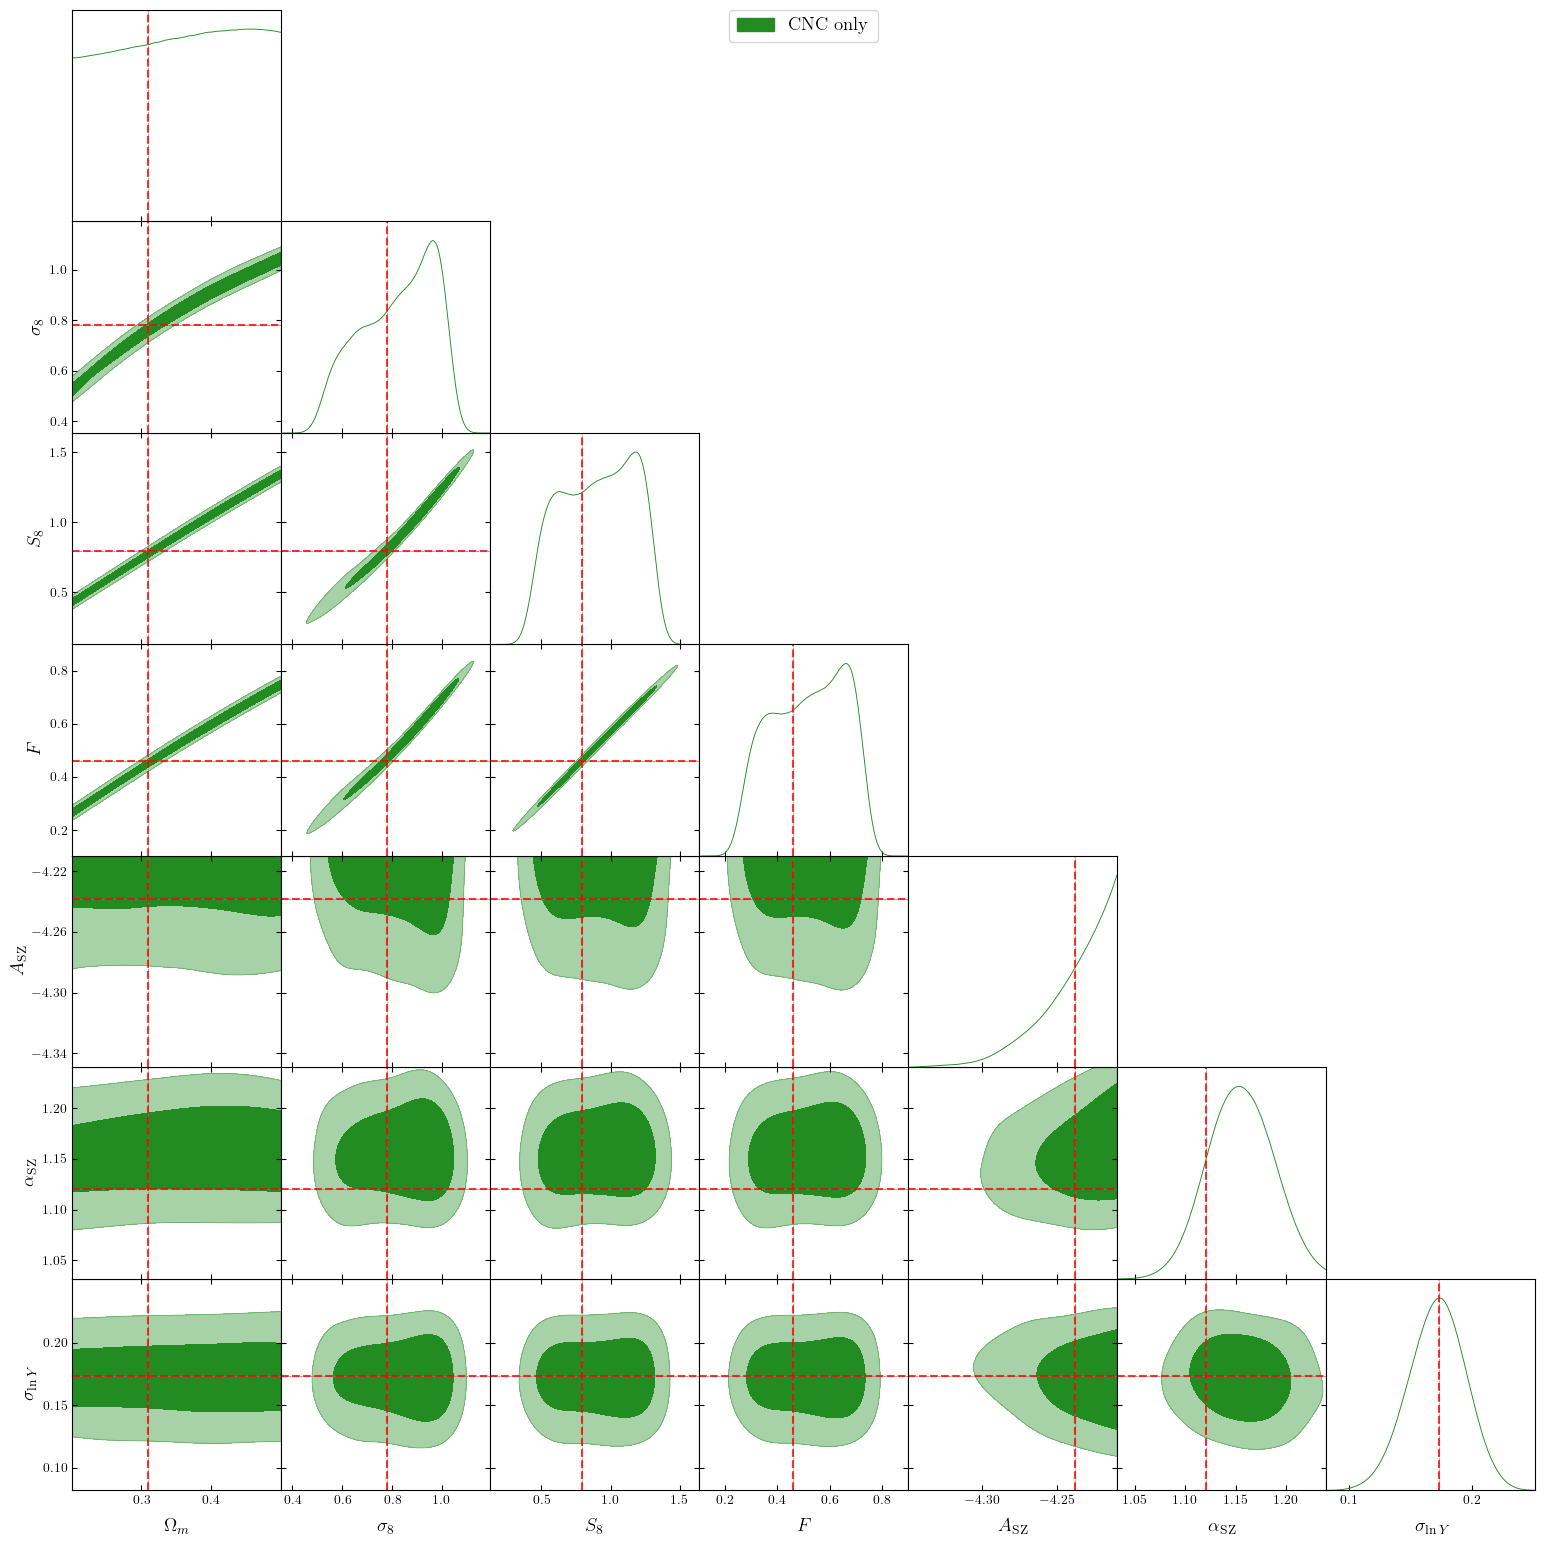

In [16]:
params_to_plot = [
    "Omega_m",
    "sigma8",
    "S8",
    "F",
    "A_SZ",
    "alpha_SZ",
    "sigma_lnY",
]

g = plots.get_subplot_plotter(width_inch=16)
g.settings.lab_fontsize = 16
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 16

g.triangle_plot(
    [samples_cnc],
    params_to_plot,
    filled=True,
    contour_colors=["forestgreen"],
    legend_labels=["CNC only"],
    markers={k: fid[k] for k in params_to_plot if k in fid},
)

# ---- True parameter values (red dashed lines) ----
vline_style = {"color": "red", "ls": "--", "lw": 1.5, "alpha": 0.8}
hline_style = {"color": "red", "ls": "--", "lw": 1.5, "alpha": 0.8}

for i, p1 in enumerate(params_to_plot):
    for j, p2 in enumerate(params_to_plot):
        ax = g.subplots[i, j]
        if ax is None:
            continue
        if i == j:
            ax.axvline(fid[p1], **vline_style)
        else:
            ax.axvline(fid[p2], **vline_style)
            ax.axhline(fid[p1], **hline_style)

plt.savefig(
    "/scratch/scratch-lxu/compute_packages/cosmocnc_jax/tutorials/triangle_cnc_only.png",
    dpi=300,
)
plt.show()
